# Segmentering af telekundeabonnenter med k-means-klyngeanalyse

## Sammenfatning

Et teleselskab ønsker at inddele sin base af abonnenter med efterbetalt abonnement i adfærdsmæssige segmenter, så det kan målrette fastholdelsestilbud og tilpasse dataplaner. Denne notebook genererer et syntetisk datasæt for abonnentforbrug og kører derefter en komplet k-means-segmenteringspipeline i Base SAS: standardiser forbrugsdrivere med **PROC STDIZE**, vælg antallet af klynger ved at sammenligne pseudo-F-statistikken på tværs af kandidat-k med **PROC FASTCLUS**, tilpas en FREKVENS-vægtet endelig model, der scorer hver abonnent, og eksporter de lærte centroider, så næste måneds øjebliksbillede kan scores uden gen-klyngedannelse. Resultatet er en genanvendelig segmentering, der oversætter rå forbrugstelemetri til en fastholdelsesplan.

## Datakilder

**Syntetisk datasæt: `WORK.SUBSCRIBERS`** (100 mobilabonnenter med efterbetaling, genereret direkte med `call streaminit(20260531)`)

| Variabel | Type | Rolle | Beskrivelse |
|----------|------|-------|-------------|
| `cust_id` | Char | ID | Abonnentidentifikator (fx `SUB000123`) |
| `tenure_months` | Num | Intervalinput | Antal måneder linjen har været aktiv (1-72) |
| `data_gb` | Num | Intervalinput | Gennemsnitligt månedligt mobildataforbrug, i GB |
| `voice_min` | Num | Intervalinput | Gennemsnitlige månedlige taleminutter |
| `intl_min` | Num | Intervalinput | Gennemsnitlige månedlige internationale minutter |
| `support_calls` | Num | Intervalinput | Support-/kundeservicehenvendelser de seneste 90 dage |
| `monthly_charge` | Num | Intervalinput | Nuværende månedlig regning, i dollar |
| `plan_tier` | Char | Profilering | Abonnementstype: `Basis`, `Plus` eller `Ubegrænset` |
| `n_lines` | Num | FREKVENS-vægt | Antal linjer på kontoen |

Tre latente adfærdsprofiler er indlejret i generatoren - *let/prisbevidst*, *datatung/streaming* og *behovstung/i risiko* - så klyngedannelsen har reel struktur at genfinde. Intervaldrivere fødes ind i k-means-modellen; `plan_tier` holdes udenfor til efterfølgende profilering, og `n_lines` vægter hver konto efter antal linjer. Der anvendes ingen eksterne filer eller netværksadgang.

## Adfærdssegmentering i fem trin

Teleselskaber har millioner af efterbetalte linjer, og en ensartet fastholdelsesstrategi spilder margin på kunder, der alligevel ville blive, mens den overser dem, der er ved at forsvinde. **Adfærdssegmentering** omdanner rå forbrugstelemetri til nogle få handlingsorienterede kundetyper: *let/prisbevidste* brugere, der er prisfølsomme, *datatunge streamere*, der er gode opsalgsmål, og *behovstunge/i risiko*-konti, der har brug for proaktiv pleje.

Denne notebook opbygger segmenteringen med `PROC FASTCLUS`, SAS' k-means-procedure (disjunkt klyngeanalyse). Vi vil:

1. Generere et syntetisk, men realistisk datasæt for abonnentforbrug.
2. Sætte forbrugsdriverne på en fælles skala med **PROC STDIZE**.
3. **Vælge antallet af klynger** ved at sammenligne pseudo-F-statistikken på tværs af kandidat-k.
4. Tilpasse en FREKVENS-vægtet endelig model, der **scorer** hver abonnent og profilerer segmenterne.
5. **Eksportere de lærte centroider**, så modellen kan genanvendes på næste måneds øjebliksbillede.

## Trin 1 - Generer en syntetisk abonnentbase

Vi simulerer 100 efterbetalte abonnenter. Hver er trukket fra en af tre latente profiler med forskellige forbrugssignaturer, så der er reel klyngestruktur at genfinde. Vi fikserer stikprøvestrømmen med `call streaminit` for reproducerbarhed og begrænser de simulerede værdier til realistiske intervaller med `max`/`min`/`round`.

Den nominelle `plan_tier` er korreleret med den latente profil (streamere hælder mod *Ubegrænset*; prisbevidste brugere mod *Basis*), og `n_lines` vil senere fungere som en FREKVENS-vægt, så familiekonti med flere linjer tæller proportionalt.

In [1]:
data subscribers;
    CALL streaminit(20260531);
    LÆNGDE cust_id $9 plan_tier $12;
    GØR i = 1 TIL 100;
        cust_id = cats('SUB', SKRIV_V(i, z6.));

        /* Tre latente adfærdsprofiler, ~ulige forekomst */
        u = rand('uniform');
        HVIS u < 0.45 SÅ profile = 1;        /* let / prisbevidst        */
        ELLERS HVIS u < 0.80 SÅ profile = 2;   /* datatung streamer        */
        ELLERS profile = 3;                    /* behovstung / i risiko    */

        HVIS profile = 1 SÅ GØR;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        SLUT;
        ELLERS HVIS profile = 2 SÅ GØR;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        SLUT;
        ELLERS GØR;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        SLUT;

        /* Abonnementstype korreleret med profil */
        p = rand('uniform');
        HVIS profile = 1 SÅ
            plan_tier = ifc(p < 0.70, 'Basis', ifc(p < 0.95, 'Plus', 'Ubegrænset'));
        ELLERS HVIS profile = 2 SÅ
            plan_tier = ifc(p < 0.65, 'Ubegrænset', ifc(p < 0.90, 'Plus', 'Basis'));
        ELLERS
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Ubegrænset', 'Basis'));

        /* Linjer på kontoen: de fleste har kun én linje */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Afrund monetære/forbrugsværdier til realistisk præcision */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        UDDATA;
    SLUT;
    FJERN i u p profile;
KØR;

PROCEDURE UDSKRIV data=subscribers(obs=10) MÆRKAT noobs;
    MÆRKAT cust_id="Kunde-ID" plan_tier="Abonnementstype" tenure_months="Kundeforhold (mdr.)"
          data_gb="Data (GB/md.)" voice_min="Taleminutter (md.)" intl_min="Int. minutter (md.)"
          support_calls="Supporthenvendelser (90 dage)" monthly_charge="Månedlig regning ($)"
          n_lines="Antal linjer";
    TITEL "Stikprøve af syntetiske abonnentforbrugsdata";
KØR;


                                      Stikprøve af syntetiske abonnentforbrugsdata                                      

 Kunde-ID  Abonnementstype  Kundeforhold (mdr.)  Data (GB/md.)  Taleminutter (md.)  Int. minutter (md.)  Supporthenvendelser (90 dage)   Månedlig regning ($)  Antal linjer
SUB000001  Basis                             15            9.7                 114                    5                             11                  57.07             2
SUB000002  Basis                             39            0.6                 214                    2                              1                  35.88             3
SUB000003  Ubegrænset                        45           23.9                 325                    6                              1                 103.94             2
SUB000004  Basis                             41            1.9                 202                    1                              0                  61.69             3
SUB000005  Basis  


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Trin 2 - Sæt driverne på en fælles skala

k-means bruger euklidisk afstand, så en variabel med stor størrelsesorden som taleminutter ville dominere en variabel med lille størrelsesorden som supporthenvendelser, hvis vi klyngede på de rå værdier. Den standardmæssige løsning er at standardisere hver intervaldriver til middelværdi 0 og standardafvigelse 1 først. **PROC STDIZE** med `METHOD=STD` gør netop det og skriver den z-scorede kopi til `WORK.SUBS_STD`. Vi bærer `cust_id`, `plan_tier` og `n_lines` uændret med, så de er tilgængelige til vægtning og profilering senere.

In [2]:
PROCEDURE stdize data=subscribers out=subs_std METHOD=std;
    VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
KØR;

PROCEDURE GENNEMSNIT data=subs_std mean std maxdec=3;
    VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    MÆRKAT tenure_months="Kundeforhold (mdr.)" data_gb="Data (GB/md.)" voice_min="Taleminutter (md.)"
          intl_min="Int. minutter (md.)" support_calls="Supporthenvendelser (90 dage)"
          monthly_charge="Månedlig regning ($)";
    TITEL "Standardiserede drivvariable: Middelværdi ~ 0, Std ~ 1";
KØR;


                                      Stikprøve af syntetiske abonnentforbrugsdata                                      

                                 Standardiserede drivvariable: Middelværdi ~ 0, Std ~ 1                                 

                                                  The MEANS Procedure

 Variable        Label                                   Mean     Std Dev
 ------------------------------------------------------------------------
 tenure_months   Kundeforhold (mdr.)                    0.000       1.000
 data_gb         Data (GB/md.)                         -0.000       1.000
 voice_min       Taleminutter (md.)                    -0.000       1.000
 intl_min        Int. minutter (md.)                    0.000       1.000
 support_calls   Supporthenvendelser (90 dage)         -0.000       1.000
 monthly_charge  Månedlig regning ($)                   0.000       1.000
 ------------------------------------------------------------------------




NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Trin 3 - Hvor mange segmenter? Sammenlign pseudo-F på tværs af kandidat-k

I stedet for at gætte på antallet af klynger tilpasser vi FASTCLUS ved hver kandidat-k og aflæser de model-fit-statistikker, den rapporterer. **Pseudo-F-statistikken** (et forhold mellem varians mellem klynger og varians inden for klynger) og den **samlede R-kvadreret** belønner begge separation; et godt k er der, hvor pseudo-F er høj, og hvor endnu en klynge giver aftagende udbytte. En kort makro-løkke kører k = 2, 3, 4 med `MAXITER=50` og `CONVERGE=0` (iterér til stabilitet). Sammenlign linjerne `Pseudo F Statistic` og `Overall R-Squared` i de tre nedenstående oversigter: den indlejrede struktur har tre latente profiler, og k = 3 giver den stærkeste, mest balancerede løsning.

In [3]:
%macro pick_k;
    %GØR k = 2 %TIL 4;
        PROCEDURE FASTCLUS data=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            TITEL "Kandidatantal klynger: k = &k";
        KØR;
    %SLUT;
%mend pick_k;
%pick_k;


                                 Standardiserede drivvariable: Middelværdi ~ 0, Std ~ 1                                 


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Trin 4 - Tilpas den endelige segmentering og score hver abonnent

Med k = 3 valgt tilpasser vi produktionsmodellen. Dette kørsel er fuldt idiomatisk for en operationel segmentering:

- `FREQ`-sætningen vægter hver konto efter `n_lines`, så en firelinjers familiekonto bidrager fire gange så meget som en enkelt linje, når centroiderne beregnes.
- `OUT=SCORED` skriver hver abonnent med sin tildelte `CLUSTER` og sin `DISTANCE` til den klynges centroide; `ID`-sætningen bærer `cust_id` med ind i den scorede tabel.
- `MEAN=SEG_MEANS` fanger centroiderne pr. klynge (på den standardiserede skala).
- `OUTSEED=SEG_SEEDS` gemmer de endelige centroider i det seed-format, FASTCLUS kan læse tilbage - dette er den eksporterede model, vi genanvender i Trin 6.

Model-fit-statistikkerne blev allerede fastlagt i Trin 3-gennemgangen, så vi tilføjer `SHORT`-tilvalget her for at holde oversigten fokuseret på de klyngestørrelser og centroider, der driver scoringsoutputtet.

In [4]:
PROCEDURE FASTCLUS data=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    FREKVENSER n_lines;
    id cust_id;
    TITEL "Endelig segmentering: k = 3, FREKVENS-vægtet efter antal linjer";
KØR;

PROCEDURE UDSKRIV data=seg_means MÆRKAT noobs;
    MÆRKAT tenure_months="Kundeforhold (mdr.)" data_gb="Data (GB/md.)" voice_min="Taleminutter (md.)"
          intl_min="Int. minutter (md.)" support_calls="Supporthenvendelser (90 dage)"
          monthly_charge="Månedlig regning ($)";
    TITEL "Segmentcentroider (standardiseret skala)";
KØR;


                                 Standardiserede drivvariable: Middelværdi ~ 0, Std ~ 1                                 


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Trin 5 - Profilér segmenterne i forretningsenheder

Den scorede tabel bærer hver abonnents `CLUSTER`-tildeling, men på den standardiserede skala er centroiderne svære at aflæse. For at omdanne klyngenumre til forretningspersonaer sammenkæder vi tildelingen tilbage til den oprindelige `subscribers`-tabel og profilerer i rigtige enheder - gigabyte, minutter og dollar. PROC MEANS opsummerer intervaldriverne efter segment, og PROC FREQ krydstabulerer den udeladte `plan_tier` mod segmentet for at vise hver personas abonnementssammensætning.

                       Segmentprofiler: Gennemsnitligt forbrug efter klynge (oprindelige enheder)                       

                                                  The MEANS Procedure

                                 Analysis Variable : tenure_months Kundeforhold (mdr.)

                                         N
                             Klynge    Obs      Mean      Std Dev      Minimum      Maximum
                             --------------------------------------------------------------
                             1          51      33.2         14.7          1.0         61.0
                             2          31      40.5         14.0         17.0         67.0
                             3          18      12.7          7.1          1.0         30.0
                             --------------------------------------------------------------

                                       Analysis Variable : data_gb Data (GB/md.)

                                         


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


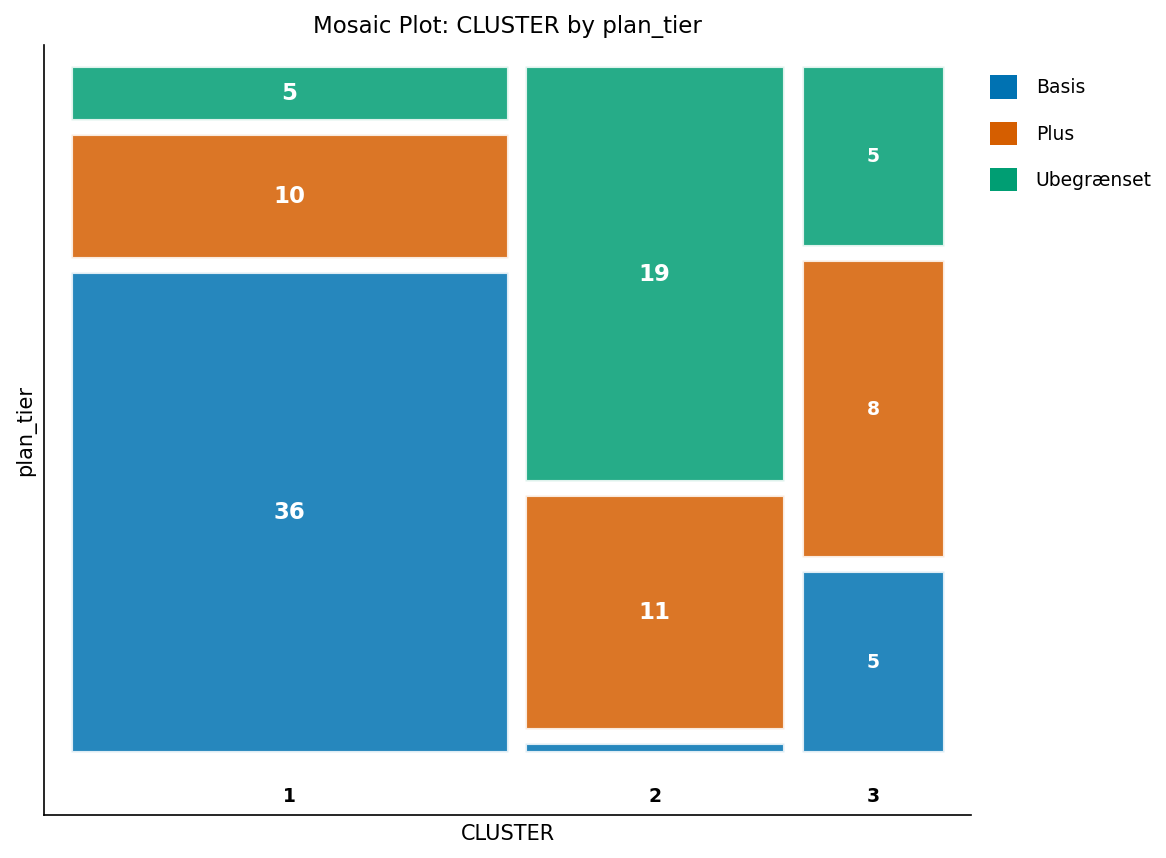

In [5]:
PROCEDURE SORTER data=scored out=scored_keys(BEHOLD=cust_id CLUSTER);
    EFTER cust_id;
KØR;

PROCEDURE SORTER data=subscribers out=subs_sorted;
    EFTER cust_id;
KØR;

data profile;
    SAMMENFLET subs_sorted(IN=a) scored_keys(IN=b);
    EFTER cust_id;
    HVIS a AND b;
KØR;

PROCEDURE GENNEMSNIT data=profile mean std MIN MAX maxdec=1;
    KLASSE CLUSTER;
    VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    MÆRKAT CLUSTER="Klynge" tenure_months="Kundeforhold (mdr.)" data_gb="Data (GB/md.)"
          voice_min="Taleminutter (md.)" intl_min="Int. minutter (md.)"
          support_calls="Supporthenvendelser (90 dage)" monthly_charge="Månedlig regning ($)";
    TITEL "Segmentprofiler: Gennemsnitligt forbrug efter klynge (oprindelige enheder)";
KØR;

PROCEDURE FREKVENSER data=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    MÆRKAT CLUSTER="Klynge" plan_tier="Abonnementstype";
    TITEL "Abonnementsfordeling inden for hvert segment";
KØR;


## Trin 6 - Genanvend modellen på næste måneds øjebliksbillede

En segmentering er kun nyttig, hvis den kan genanvendes uden at genkøre hele jobbet. De centroider, vi gemte til `SEG_SEEDS` i Trin 4, er en portabel model: at fodre dem tilbage som `SEED=SEG_SEEDS` med `MAXITER=0` fortæller FASTCLUS at *tildele* hver observation til dens nærmeste gemte centroide uden at flytte centroiderne - ren scoring, ikke gen-tilpasning. Her scorer vi det samme standardiserede øjebliksbillede igen for at bekræfte, at den eksporterede model reproducerer de oprindelige tildelinger; i produktion ville man pege `DATA=` på næste måneds standardiserede øjebliksbillede i stedet.

                                      Abonnementsfordeling inden for hvert segment                                      


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


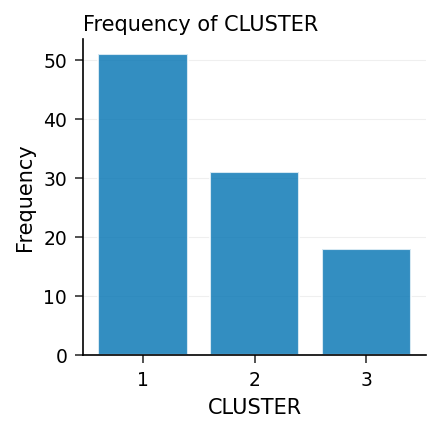

In [6]:
PROCEDURE FASTCLUS data=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    TITEL "Scoring af et nyt øjebliksbillede ud fra de eksporterede centroider";
KØR;

PROCEDURE FREKVENSER data=rescored;
    TABLES CLUSTER / nocum;
    MÆRKAT CLUSTER="Klynge";
    TITEL "Abonnenter gen-scoret via den eksporterede model";
KØR;


## Fortolkning af resultaterne

FASTCLUS genfandt de tre adfærdssegmenter, der er indlejret i dataene, og profileringstabellerne oversætter dem til en fastholdelsesplan. Aflæs segmentnumrene fra tabellen *Segmentprofiler* ovenfor - klyngeetiketterne er vilkårlige, så identificér hver persona ud fra dens forbrugssignatur:

- **Let/prisbevidste brugere** - lavt dataforbrug, beskedne regninger, længere kundeforhold, meget få supporthenvendelser, mest på *Basis*. Disse kunder er stabile og prisfølsomme; det rigtige træk er at *beskytte marginen*, ikke at rabattere. En rigtig tilpasset planbefaling forhindrer regningschok uden gratis ekstraydelser.
- **Datatunge streamere** - højt dataforbrug, høje tale- og internationale minutter, premium-regninger, mest *Ubegrænset*. De er loyale og højværdi: spillet er *opsalg og enhedsopgraderinger*, plus proaktiv besked om netværkskvalitet, så en konkurrents tilbud ikke kan lokke dem væk.
- **Behovstunge/i risiko** - kort kundeforhold, forhøjet antal supporthenvendelser, mellemklasseforbrug. De hyppige plejehenvendelser plus lavt kundeforhold er klassiske tegn på frafald. Dette er segmentet, der fortjener et *proaktivt fastholdelsestilbud* og en opfølgning på serviceoprettelse.

Vigtige procedurevalg, der gjorde dette pålideligt: **PROC STDIZE** forhindrede taleminutter med stor størrelsesorden i at overdøve supporthenvendelses-signalet; pseudo-F-gennemgangen begrundede antallet af klynger frem for at gætte det; `FREQ`-vægten fik familiekonti med flere linjer til at tælle proportionalt med deres fodaftryk; og `OUTSEED=`/`SEED=`-rundturen eksporterede centroiderne, så marketingteamet kan gensegmentere hvert måneds øjebliksbillede med et enkelt `MAXITER=0`-FASTCLUS-kald - ingen gen-klyngedannelse nødvendig.